In [7]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact
from scipy.stats import pearsonr
from scipy.stats import pointbiserialr

import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Probit
from stargazer.stargazer import Stargazer

pd.set_option('display.max_rows', 500)

In [8]:
dg = pd.read_excel('../../data/interim/02_appended/delegator_full.xlsx')
ev = pd.read_excel('../../data/interim/02_appended/evaluator_full.xlsx')

In [9]:
dg['female'] = np.nan
dg.loc[dg['Sex']=='Female', 'female'] = 1
dg.loc[dg['Sex']=='Male', 'female'] = 0

dg['pass_att1'] = 0
dg.loc[dg['test_slider']==207, 'pass_att1'] = 1
dg['pass_att2'] = 0
dg.loc[dg['attention']==0.5, 'pass_att2'] = 1

#weighted average confidence
dg['wa_confidence'] = np.nan
for i in range(dg.shape[0]):
    wa = 0
    for j in range(11):
        wa += (dg['confidence' + str(j)][i]/100)*j
    dg.loc[i, 'wa_confidence'] = wa

# overconfidence within subject
dg['overconfidence'] = dg['wa_confidence']-dg['participant.overall_score']

#weighted average difficulty
dg['wa_difficulty'] = np.nan
for i in range(dg.shape[0]):
    wa = 0
    for j in range(11):
        wa += (dg['difficulty' + str(j)][i]/100)*j
    dg.loc[i, 'wa_difficulty'] = wa

#overconfidence compared to others
dg['overconfidence_to_others'] = dg['wa_confidence']-dg['wa_difficulty']

#create var for diff in beliefs
dg['bad_good_del'] = dg['belief_del_bad'] - dg['belief_del_good']
dg['bad_good_nodel'] = dg['belief_nodel_bad'] - dg['belief_nodel_good']
dg['nodel_del_good'] = dg['belief_nodel_good'] - dg['belief_del_good']
dg['nodel_del_bad'] = dg['belief_nodel_bad'] - dg['belief_del_bad']

#interactions with treat
dg['nodel_del_good_x_treat'] = dg['nodel_del_good']*dg['treat']
dg['nodel_del_bad_x_treat'] = dg['nodel_del_bad']*dg['treat']

#convert risk task switching point to interval
dg.loc[dg['switching_point']==9999, 'switching_point'] = 110

ev['female'] = np.nan
ev.loc[ev['Sex']=='Female', 'female'] = 1
ev.loc[ev['Sex']=='Male', 'female'] = 0

#calculate weighted average
ev['wa_difficulty'] = np.nan
for i in range(ev.shape[0]):
    wa = 0
    for j in range(11):
        wa += (ev['difficulty' + str(j)][i]/100)*j
    ev.loc[i, 'wa_difficulty'] = wa

ev['pass_att2'] = 0
ev.loc[ev['attention']==0.5, 'pass_att2'] = 1

#create variable for people that never punish
ev['never_punish'] = 0
ev.loc[(ev['punish_del_good'] == 0) & (ev['punish_del_bad'] == 0) & (ev['punish_nodel_bad'] == 0) & (ev['punish_nodel_good'] == 0), 'never_punish'] = 1

#punishment differences
ev['bad_good_del'] = ev['punish_del_bad'] - ev['punish_del_good']
ev['bad_good_nodel'] = ev['punish_nodel_bad'] - ev['punish_nodel_good']
ev['nodel_del_good'] = ev['punish_nodel_good'] - ev['punish_del_good']
ev['nodel_del_bad'] = ev['punish_nodel_bad'] - ev['punish_del_bad']

#frequency of punishment variable
for i in ['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']:
    ev[i+'_bin'] = 0
    ev.loc[ev[i]>0, i+'_bin'] = 1

#convert risk task switching point to interval
ev.loc[ev['switching_point']==9999, 'switching_point'] = 110

# Graphs

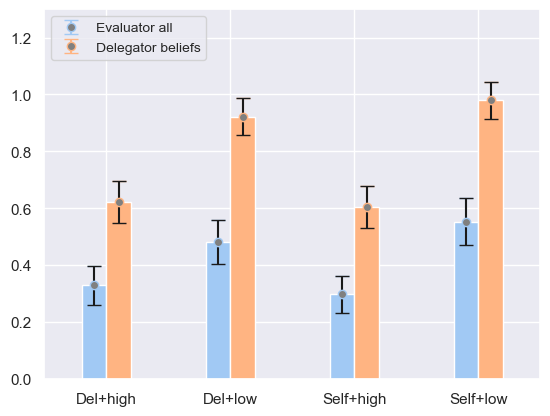

In [16]:
sns.set_theme()
sns.set_palette("pastel")

a=0.1 
t_all = ev[(ev['treat']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos = ev[(ev['treat']==0) & (ev['never_punish']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos_rat = ev[(ev['treat']==0) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T

dg_all = dg[(dg['treat']==0)][['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].agg(['mean', 'sem']).T
dg_pos = dg[(dg['treat']==0) & (ev['never_punish']==0)][['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].agg(['mean', 'sem']).T
dg_pos_rat = dg[(dg['treat']==0) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].agg(['mean', 'sem']).T

plt.errorbar([i-a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], fmt='o', capsize=5, label='Evaluator all', markerfacecolor='grey')
plt.bar([i-a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], capsize=5, width=0.2)

#plt.errorbar([1, 2, 3, 4], t_pos['mean'], yerr=t_pos['sem'], fmt='o', capsize=5, label='pos. punish', markerfacecolor='grey')
#plt.bar([1, 2, 3, 4], t_pos['mean'], yerr=t_pos['sem'], capsize=5, width=0.2)
                                                             
#plt.errorbar([i+a for i in [1, 2, 3, 4]], t_pos_rat['mean'], yerr=t_pos_rat['sem'], fmt='o', capsize=5, label='pos. punish (cleaned)', markerfacecolor='grey')
#plt.bar([i+a for i in [1, 2, 3, 4]], t_pos_rat['mean'], yerr=t_pos_rat['sem'], capsize=5, width=0.2)

plt.errorbar([i+a for i in [1, 2, 3, 4]], dg_all['mean'], yerr=dg_all['sem'], fmt='o', capsize=5, label='Delegator beliefs', markerfacecolor='grey')
plt.bar([i+a for i in [1, 2, 3, 4]], dg_all['mean'], yerr=dg_all['sem'], capsize=5, width=0.2)

#plt.errorbar([i+a for i in [1, 2, 3, 4]], dg_pos['mean'], yerr=dg_pos['sem'], fmt='o', capsize=5, label='Delegator beliefs', markerfacecolor='grey')
#plt.bar([i+a for i in [1, 2, 3, 4]], dg_pos['mean'], yerr=dg_pos['sem'], capsize=5, width=0.2)

#plt.errorbar([i+a for i in [1, 2, 3, 4]], dg_pos_rat['mean'], yerr=dg_pos_rat['sem'], fmt='o', capsize=5, label='Delegator beliefs', markerfacecolor='grey')
#plt.bar([i+a for i in [1, 2, 3, 4]], dg_pos_rat['mean'], yerr=dg_pos_rat['sem'], capsize=5, width=0.2)

plt.xlim(0.5, 4.5)
plt.ylim(0, 1.3)
plt.xticks([1, 2, 3, 4], ['Del+high', 'Del+low', 'Self+high', 'Self+low'])
plt.legend(fontsize='small', loc='upper left')
#plt.savefig('punish3.png', dpi=300, bbox_inches='tight')
plt.show()


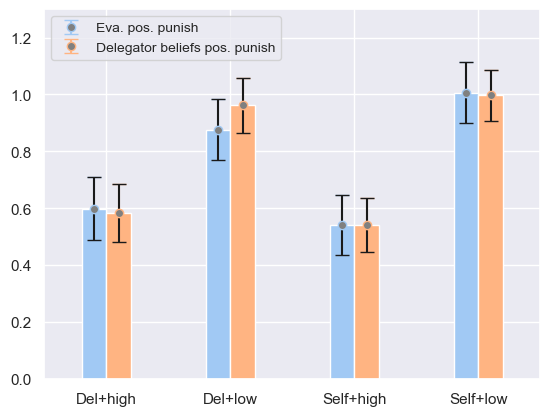

In [19]:
sns.set_theme()
sns.set_palette("pastel")

a=0.1 
t_all = ev[(ev['treat']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos = ev[(ev['treat']==0) & (ev['never_punish']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos_rat = ev[(ev['treat']==0) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T

dg_all = dg[(dg['treat']==0)][['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].agg(['mean', 'sem']).T
dg_pos = dg[(dg['treat']==0) & (ev['never_punish']==0)][['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].agg(['mean', 'sem']).T
dg_pos_rat = dg[(dg['treat']==0) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].agg(['mean', 'sem']).T

#plt.errorbar([i-a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], fmt='o', capsize=5, label='Evaluator all', markerfacecolor='grey')
#plt.bar([i-a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], capsize=5, width=0.2)

plt.errorbar([i-a for i in [1, 2, 3, 4]], t_pos['mean'], yerr=t_pos['sem'], fmt='o', capsize=5, label='Eva. pos. punish', markerfacecolor='grey')
plt.bar([i-a for i in [1, 2, 3, 4]], t_pos['mean'], yerr=t_pos['sem'], capsize=5, width=0.2)
                                                             
#plt.errorbar([i+a for i in [1, 2, 3, 4]], t_pos_rat['mean'], yerr=t_pos_rat['sem'], fmt='o', capsize=5, label='pos. punish (cleaned)', markerfacecolor='grey')
#plt.bar([i+a for i in [1, 2, 3, 4]], t_pos_rat['mean'], yerr=t_pos_rat['sem'], capsize=5, width=0.2)

#plt.errorbar([i+a for i in [1, 2, 3, 4]], dg_all['mean'], yerr=dg_all['sem'], fmt='o', capsize=5, label='Delegator beliefs', markerfacecolor='grey')
#plt.bar([i+a for i in [1, 2, 3, 4]], dg_all['mean'], yerr=dg_all['sem'], capsize=5, width=0.2)

plt.errorbar([i+a for i in [1, 2, 3, 4]], dg_pos['mean'], yerr=dg_pos['sem'], fmt='o', capsize=5, label='Delegator beliefs pos. punish', markerfacecolor='grey')
plt.bar([i+a for i in [1, 2, 3, 4]], dg_pos['mean'], yerr=dg_pos['sem'], capsize=5, width=0.2)

#plt.errorbar([i+a for i in [1, 2, 3, 4]], dg_pos_rat['mean'], yerr=dg_pos_rat['sem'], fmt='o', capsize=5, label='Delegator beliefs', markerfacecolor='grey')
#plt.bar([i+a for i in [1, 2, 3, 4]], dg_pos_rat['mean'], yerr=dg_pos_rat['sem'], capsize=5, width=0.2)

plt.xlim(0.5, 4.5)
plt.ylim(0, 1.3)
plt.xticks([1, 2, 3, 4], ['Del+high', 'Del+low', 'Self+high', 'Self+low'])
plt.legend(fontsize='small', loc='upper left')
#plt.savefig('punish3.png', dpi=300, bbox_inches='tight')
plt.show()

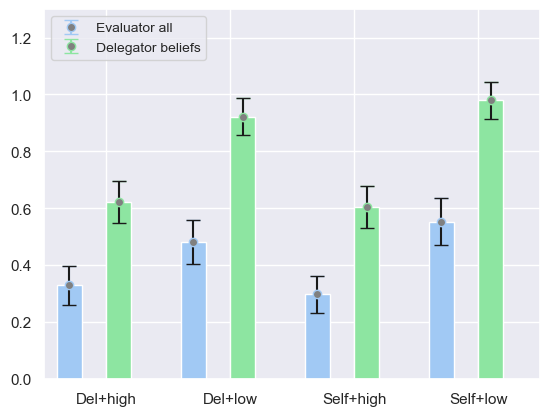

In [30]:
sns.set_theme()
sns.set_palette("pastel")

a=0.2 
t_all = ev[(ev['treat']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos = ev[(ev['treat']==0) & (ev['never_punish']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
#t_pos_rat = ev[(ev['treat']==0) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T

dg_all = dg[(dg['treat']==0)][['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].agg(['mean', 'sem']).T
dg_pos = dg[(dg['treat']==0) & (ev['never_punish']==0)][['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].agg(['mean', 'sem']).T
#dg_pos_rat = dg[(dg['treat']==0) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].agg(['mean', 'sem']).T

plt.errorbar([i-1.5*a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], fmt='o', capsize=5, label='Evaluator all', markerfacecolor='grey')
plt.bar([i-1.5*a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], capsize=5, width=0.2)

#plt.errorbar([i-0.5*a for i in [1, 2, 3, 4]], t_pos['mean'], yerr=t_pos['sem'], fmt='o', capsize=5, label='Eva. pos. punish', markerfacecolor='grey')
#plt.bar([i-0.5*a for i in [1, 2, 3, 4]], t_pos['mean'], yerr=t_pos['sem'], capsize=5, width=0.2)
                                                             
#plt.errorbar([i+a for i in [1, 2, 3, 4]], t_pos_rat['mean'], yerr=t_pos_rat['sem'], fmt='o', capsize=5, label='pos. punish (cleaned)', markerfacecolor='grey')
#plt.bar([i+a for i in [1, 2, 3, 4]], t_pos_rat['mean'], yerr=t_pos_rat['sem'], capsize=5, width=0.2)

plt.errorbar([i+0.5*a for i in [1, 2, 3, 4]], dg_all['mean'], yerr=dg_all['sem'], fmt='o', capsize=5, label='Delegator beliefs', markerfacecolor='grey', color=sns.color_palette("pastel")[2])
plt.bar([i+0.5*a for i in [1, 2, 3, 4]], dg_all['mean'], yerr=dg_all['sem'], capsize=5, width=0.2, color=sns.color_palette("pastel")[2])

#plt.errorbar([i+1.5*a for i in [1, 2, 3, 4]], dg_pos['mean'], yerr=dg_pos['sem'], fmt='o', capsize=5, label='Delegator beliefs pos. punish', markerfacecolor='grey')
#plt.bar([i+1.5*a for i in [1, 2, 3, 4]], dg_pos['mean'], yerr=dg_pos['sem'], capsize=5, width=0.2)

#plt.errorbar([i+a for i in [1, 2, 3, 4]], dg_pos_rat['mean'], yerr=dg_pos_rat['sem'], fmt='o', capsize=5, label='Delegator beliefs', markerfacecolor='grey')
#plt.bar([i+a for i in [1, 2, 3, 4]], dg_pos_rat['mean'], yerr=dg_pos_rat['sem'], capsize=5, width=0.2)

plt.xlim(0.5, 4.5)
plt.ylim(0, 1.3)
plt.xticks([1, 2, 3, 4], ['Del+high', 'Del+low', 'Self+high', 'Self+low'])
plt.legend(fontsize='small', loc='upper left')
plt.savefig('ev_dg1.png', dpi=300, bbox_inches='tight')
plt.show()

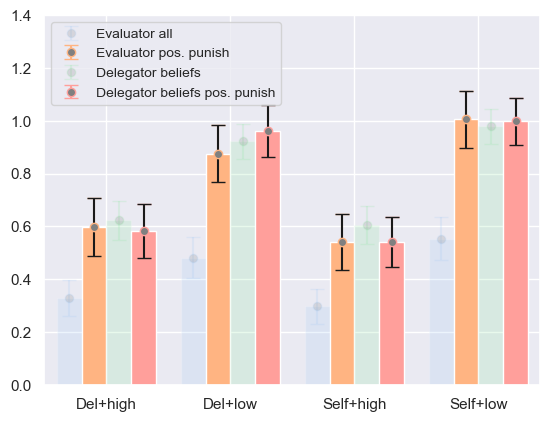

In [51]:
sns.set_theme()
sns.set_palette("pastel")

a=0.2 
t_all = ev[(ev['treat']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos = ev[(ev['treat']==0) & (ev['never_punish']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
#t_pos_rat = ev[(ev['treat']==0) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T

dg_all = dg[(dg['treat']==0)][['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].agg(['mean', 'sem']).T
dg_pos = dg[(dg['treat']==0) & (ev['never_punish']==0)][['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].agg(['mean', 'sem']).T
#dg_pos_rat = dg[(dg['treat']==0) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].agg(['mean', 'sem']).T

plt.errorbar([i-1.5*a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], fmt='o', capsize=5, label='Evaluator all', markerfacecolor='grey', alpha=0.2)
plt.bar([i-1.5*a for i in [1, 2, 3, 4]], t_all['mean'], capsize=5, width=0.2, alpha=0.2)

plt.errorbar([i-0.5*a for i in [1, 2, 3, 4]], t_pos['mean'], yerr=t_pos['sem'], fmt='o', capsize=5, label='Evaluator pos. punish', markerfacecolor='grey')
plt.bar([i-0.5*a for i in [1, 2, 3, 4]], t_pos['mean'], yerr=t_pos['sem'], capsize=5, width=0.2)
                                                             
#plt.errorbar([i+a for i in [1, 2, 3, 4]], t_pos_rat['mean'], yerr=t_pos_rat['sem'], fmt='o', capsize=5, label='pos. punish (cleaned)', markerfacecolor='grey')
#plt.bar([i+a for i in [1, 2, 3, 4]], t_pos_rat['mean'], yerr=t_pos_rat['sem'], capsize=5, width=0.2)

plt.errorbar([i+0.5*a for i in [1, 2, 3, 4]], dg_all['mean'], yerr=dg_all['sem'], fmt='o', capsize=5, label='Delegator beliefs', markerfacecolor='grey', alpha=0.2)
plt.bar([i+0.5*a for i in [1, 2, 3, 4]], dg_all['mean'], capsize=5, width=0.2, alpha=0.2)

plt.errorbar([i+1.5*a for i in [1, 2, 3, 4]], dg_pos['mean'], yerr=dg_pos['sem'], fmt='o', capsize=5, label='Delegator beliefs pos. punish', markerfacecolor='grey')
plt.bar([i+1.5*a for i in [1, 2, 3, 4]], dg_pos['mean'], yerr=dg_pos['sem'], capsize=5, width=0.2)

#plt.errorbar([i+a for i in [1, 2, 3, 4]], dg_pos_rat['mean'], yerr=dg_pos_rat['sem'], fmt='o', capsize=5, label='Delegator beliefs', markerfacecolor='grey')
#plt.bar([i+a for i in [1, 2, 3, 4]], dg_pos_rat['mean'], yerr=dg_pos_rat['sem'], capsize=5, width=0.2)

plt.xlim(0.5, 4.5)
plt.ylim(0, 1.4)
plt.xticks([1, 2, 3, 4], ['Del+high', 'Del+low', 'Self+high', 'Self+low'])
plt.legend(fontsize='small', loc='upper left')
plt.savefig('ev_dg2.png', dpi=300, bbox_inches='tight')
plt.show()

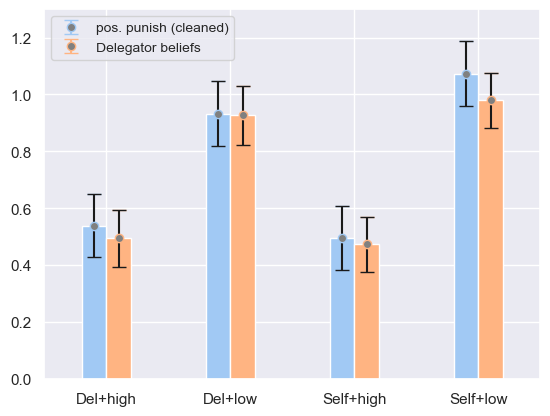

In [21]:
sns.set_theme()
sns.set_palette("pastel")

a=0.1 
t_all = ev[(ev['treat']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos = ev[(ev['treat']==0) & (ev['never_punish']==0)][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T
t_pos_rat = ev[(ev['treat']==0) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['punish_del_good', 'punish_del_bad', 'punish_nodel_good', 'punish_nodel_bad']].agg(['mean', 'sem']).T

dg_all = dg[(dg['treat']==0)][['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].agg(['mean', 'sem']).T
dg_pos = dg[(dg['treat']==0) & (ev['never_punish']==0)][['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].agg(['mean', 'sem']).T
dg_pos_rat = dg[(dg['treat']==0) & (ev['never_punish']==0) & ((ev['bad_good_del']>=0) | (ev['bad_good_nodel']>=0))][['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].agg(['mean', 'sem']).T

#plt.errorbar([i-a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], fmt='o', capsize=5, label='Evaluator all', markerfacecolor='grey')
#plt.bar([i-a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], capsize=5, width=0.2)

#plt.errorbar([i-a for i in [1, 2, 3, 4]], t_pos['mean'], yerr=t_pos['sem'], fmt='o', capsize=5, label='Eva. pos. punish', markerfacecolor='grey')
#plt.bar([i-a for i in [1, 2, 3, 4]], t_pos['mean'], yerr=t_pos['sem'], capsize=5, width=0.2)
                                                             
plt.errorbar([i-a for i in [1, 2, 3, 4]], t_pos_rat['mean'], yerr=t_pos_rat['sem'], fmt='o', capsize=5, label='pos. punish (cleaned)', markerfacecolor='grey')
plt.bar([i-a for i in [1, 2, 3, 4]], t_pos_rat['mean'], yerr=t_pos_rat['sem'], capsize=5, width=0.2)

#plt.errorbar([i+a for i in [1, 2, 3, 4]], dg_all['mean'], yerr=dg_all['sem'], fmt='o', capsize=5, label='Delegator beliefs', markerfacecolor='grey')
#plt.bar([i+a for i in [1, 2, 3, 4]], dg_all['mean'], yerr=dg_all['sem'], capsize=5, width=0.2)

#plt.errorbar([i+a for i in [1, 2, 3, 4]], dg_pos['mean'], yerr=dg_pos['sem'], fmt='o', capsize=5, label='Delegator beliefs pos. punish', markerfacecolor='grey')
#plt.bar([i+a for i in [1, 2, 3, 4]], dg_pos['mean'], yerr=dg_pos['sem'], capsize=5, width=0.2)

plt.errorbar([i+a for i in [1, 2, 3, 4]], dg_pos_rat['mean'], yerr=dg_pos_rat['sem'], fmt='o', capsize=5, label='Delegator beliefs', markerfacecolor='grey')
plt.bar([i+a for i in [1, 2, 3, 4]], dg_pos_rat['mean'], yerr=dg_pos_rat['sem'], capsize=5, width=0.2)

plt.xlim(0.5, 4.5)
plt.ylim(0, 1.3)
plt.xticks([1, 2, 3, 4], ['Del+high', 'Del+low', 'Self+high', 'Self+low'])
plt.legend(fontsize='small', loc='upper left')
#plt.savefig('punish3.png', dpi=300, bbox_inches='tight')
plt.show()